汇聚层

我们的机器学习任务通常会跟全局图像的问题有关，所以我们最后一层的神经元应该对整个输入的全局敏感。通过逐渐聚合信息，生成越来越粗糙的映射，最终实现学习全局表示的目标，同时将卷积图层的所有优势保留在中间层。

汇聚（pooling）层，它具有双重目的：降低卷积层对位置的敏感性，同时降低对空间降采样表示的敏感性。

最大汇聚层和平均汇聚层

汇聚层运算符由一个固定形状的窗口组成，该窗口根据其步幅大小在输入的所有区域上滑动，为固定形状窗口。

不同于卷积层中的输入与卷积核之间的互相关计算，汇聚层不包含参数。池运算是确定性的，计算汇聚窗口中所有元素的最大值或平均值。这些操作分别称为最大汇聚层（maximum pooling）和平均汇聚层（average pooling）。

它计算该窗口中输入子张量的最大值或平均值。计算最大值或平均值是取决于使用了最大汇聚层还是平均汇聚层。
![汇聚窗口形状为 $2\times 2$ 的最大汇聚层。着色部分是第一个输出元素，以及用于计算这个输出的输入元素: $\max(0, 1, 3, 4)=4$.](../img/pooling.svg)

下面代码中pool2d函数，实现汇聚层的前向传播

In [2]:
import torch
from torch import nn
from d2l import torch as d2l

In [3]:
def pool2d(X, pool_size, mode='max'):
    p_h, p_w = pool_size
    Y = torch.zeros((X.shape[0] - p_h + 1, X.shape[1] - p_w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            if mode == 'max':
                Y[i, j] = X[i: i + p_h, j: j + p_w].max()
            elif mode == 'avg':
                Y[i, j] = X[i: i + p_h, j: j + p_w].mean()
    return Y

最大汇聚层的输出

In [4]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
pool2d(X, (2, 2))

tensor([[4., 5.],
        [7., 8.]])

平均汇聚层

In [5]:
pool2d(X, (2, 2), 'avg')

tensor([[2., 3.],
        [5., 6.]])

汇聚层也可以通过填充和步幅以获得所需的输出形状

In [12]:
X = torch.arange(16, dtype=torch.float32).reshape((1, 1, 4, 4))
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]]]])

深度学习框架中内置的二维最大汇聚层的步幅与汇聚窗口的大小默认相同

In [8]:
pool2d = nn.MaxPool2d(3)
pool2d(X)

tensor([[[[10.]]]])

填充和步幅可以手动设定

In [9]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

设定一个任意大小的矩形汇聚窗口，并分别设定填充和步幅的高度和宽度

In [10]:
pool2d = nn.MaxPool2d((2, 3), stride=(2, 3), padding=(0, 1))
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

多个通道

处理多通道输入数据时，汇聚层在每个输入通道上单独运算，汇聚层的输出通道数与输入通道数相同。

In [11]:
X = torch.cat((X, X + 1), 1)
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]],

         [[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]]])

汇聚后输出通道的数量仍然是2。

In [13]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

## 练习

1. 尝试将平均汇聚层作为卷积层的特殊情况实现。
1. 尝试将最大汇聚层作为卷积层的特殊情况实现。
1. 假设汇聚层的输入大小为$c\times h\times w$，则汇聚窗口的形状为$p_h\times p_w$，填充为$(p_h, p_w)$，步幅为$(s_h, s_w)$。这个汇聚层的计算成本是多少？
1. 为什么最大汇聚层和平均汇聚层的工作方式不同？
1. 我们是否需要最小汇聚层？可以用已知函数替换它吗？
1. 除了平均汇聚层和最大汇聚层，是否有其它函数可以考虑（提示：回想一下`softmax`）？为什么它不流行？

In [14]:
def corr2d(X, K):
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()
    return Y

In [15]:
def avg_pool_as_conv(X, kernel_size):
    ph, pw = kernel_size
    K = torch.ones((ph, pw)) / (ph * pw)
    return corr2d(X, K)

In [17]:
X = torch.tensor([
    [1., 2., 3.],
    [4., 5., 6.],
    [7., 8., 9.]
])

Y = avg_pool_as_conv(X, (2, 2))
print(Y)

tensor([[3., 4.],
        [6., 7.]])


可以看出跟平均汇聚层效果一样

1. 尝试将最大汇聚层作为卷积层的特殊情况实现。

最大汇聚是“取最大值”，本质是非线性运算，而卷积层时线性运算，线性运算做不到“直接挑出最大那个值”。

但可以通过直接取max实现最大汇聚

In [18]:
def max_pool2d(X, kernel_size):
    ph, pw = kernel_size
    Y = torch.zeros((X.shape[0] - ph + 1, X.shape[1] - pw + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = X[i:i+ph, j:j+pw].max()
    return Y

In [19]:
X = torch.tensor([
    [1., 2., 3.],
    [4., 5., 6.],
    [7., 8., 9.]
])

Y = max_pool2d(X, (2, 2))
print(Y)

tensor([[5., 6.],
        [8., 9.]])


1. 假设汇聚层的输入大小为$c\times h\times w$，则汇聚窗口的形状为$p_h\times p_w$，填充为$(p_h, p_w)$，步幅为$(s_h, s_w)$。这个汇聚层的计算成本是多少？

In [20]:
import math

def pool_output_shape(h, w, ph, pw, sh, sw, pad_h=0, pad_w=0):
    h_out = math.floor((h + 2 * pad_h - ph) / sh) + 1
    w_out = math.floor((w + 2 * pad_w - pw) / sw) + 1
    return h_out, w_out

h_out, w_out = pool_output_shape(10, 10, 2, 2, 2, 2)
print(h_out, w_out)

5 5


1. 为什么最大汇聚层和平均汇聚层的工作方式不同？

平均汇聚强调“整体水平”，最大汇聚强调“最强响应”。

平均汇聚保留更多整体统计信息，但会把尖峰“压平”。
最大汇聚保留最显著特征，但会丢掉大量细节。

最大汇聚对“是否存在某特征”更敏感。
哪怕特征在窗口里只出现一次，只要值很大，它就能抓住。平均汇聚对噪声没那么敏感，但对局部尖锐特征也没那么敏感。

1. 我们是否需要最小汇聚层？可以用已知函数替换它吗？

可以由最大汇聚改写，如下

In [21]:
def min_pool2d(X, kernel_size):
    return -max_pool2d(-X, kernel_size)

1. 除了平均汇聚层和最大汇聚层，是否有其它函数可以考虑（提示：回想一下`softmax`）？为什么它不流行？

softmax pooling
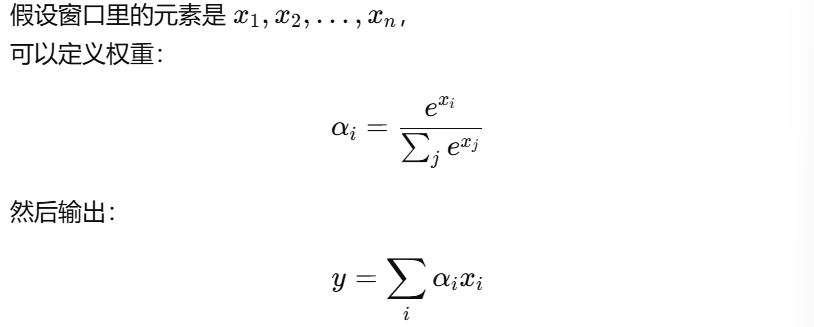
这个方法很自然，所有值差不多时就类似于平均汇聚，某个值很大时，就类似于最大汇聚

In [22]:
def softmax_pool2d(X, kernel_size):
    ph, pw = kernel_size
    Y = torch.zeros((X.shape[0] - ph + 1, X.shape[1] - pw + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            patch = X[i:i+ph, j:j+pw].reshape(-1)
            weights = torch.softmax(patch, dim=0)
            Y[i, j] = (weights * patch).sum()
    return Y

In [23]:
X = torch.tensor([
    [1., 2., 3.],
    [4., 5., 6.],
    [7., 8., 9.]
])

print(softmax_pool2d(X, (2,2)))

tensor([[4.5888, 5.5888],
        [7.5888, 8.5888]])


不流行，因为计算更复杂，因为涉及指数，所以要处理数据稳定性，